##  Property price prediction

In [1]:
## import the libraries

from warnings import filterwarnings
filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.formula.api import ols

from pandas.api.types import is_string_dtype
from pandas.api.types import is_object_dtype

from scipy import stats
from scipy.stats import shapiro


In [2]:
## set options

pd.options.display.max_columns = None
pd.options.display.max_rows = None
np.printoptions(supress = True)

In [3]:
## get the data 

df_house = pd.read_csv('HousePrices.csv')
df_house.head()

,Id,Dwell_Type,Zone_Class,LotFrontage,LotArea,Road_Type,Alley,Property_Shape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,Dwelling_Type,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,Property_Sale_Price
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df_house.shape

(1460, 81)

In [5]:
df_house = df_house.drop(['Id'], axis = 1)
df_house.shape

(1460, 80)

In [6]:
df_house.nunique()

Dwell_Type               15
Zone_Class                5
LotFrontage             110
LotArea                1073
Road_Type                 2
Alley                     2
Property_Shape            4
LandContour               4
Utilities                 2
LotConfig                 5
LandSlope                 3
Neighborhood             25
Condition1                9
Condition2                8
Dwelling_Type             5
HouseStyle                8
OverallQual              10
OverallCond               9
YearBuilt               112
YearRemodAdd             61
RoofStyle                 6
RoofMatl                  8
Exterior1st              15
Exterior2nd              16
MasVnrType                3
MasVnrArea              327
ExterQual                 4
ExterCond                 5
Foundation                6
BsmtQual                  4
BsmtCond                  4
BsmtExposure              4
BsmtFinType1              6
BsmtFinSF1              637
BsmtFinType2              6
BsmtFinSF2          

In [7]:
## describe the numerical data
df_house.describe()

,Dwell_Type,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,Property_Sale_Price
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
## describe the categorical data
df_house.describe(include = 'object')

,Zone_Class,Road_Type,Alley,Property_Shape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,Dwelling_Type,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


In [9]:
df_house.isnull().sum()

Dwell_Type                0
Zone_Class                0
LotFrontage             259
LotArea                   0
Road_Type                 0
Alley                  1369
Property_Shape            0
LandContour               0
Utilities                 0
LotConfig                 0
LandSlope                 0
Neighborhood              0
Condition1                0
Condition2                0
Dwelling_Type             0
HouseStyle                0
OverallQual               0
OverallCond               0
YearBuilt                 0
YearRemodAdd              0
RoofStyle                 0
RoofMatl                  0
Exterior1st               0
Exterior2nd               0
MasVnrType              872
MasVnrArea                8
ExterQual                 0
ExterCond                 0
Foundation                0
BsmtQual                 37
BsmtCond                 37
BsmtExposure             38
BsmtFinType1             37
BsmtFinSF1                0
BsmtFinType2             38
BsmtFinSF2          

In [10]:
df_house = df_house.drop(['PoolQC', 'MiscFeature'], axis = 1)
df_house.shape

(1460, 78)

In [11]:
df_house.head()

,Dwell_Type,Zone_Class,LotFrontage,LotArea,Road_Type,Alley,Property_Shape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,Dwelling_Type,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleType,SaleCondition,Property_Sale_Price
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,0,12,2008,WD,Normal,250000


In [12]:
plt.rcParams['figure.figsize'] = [15,8]

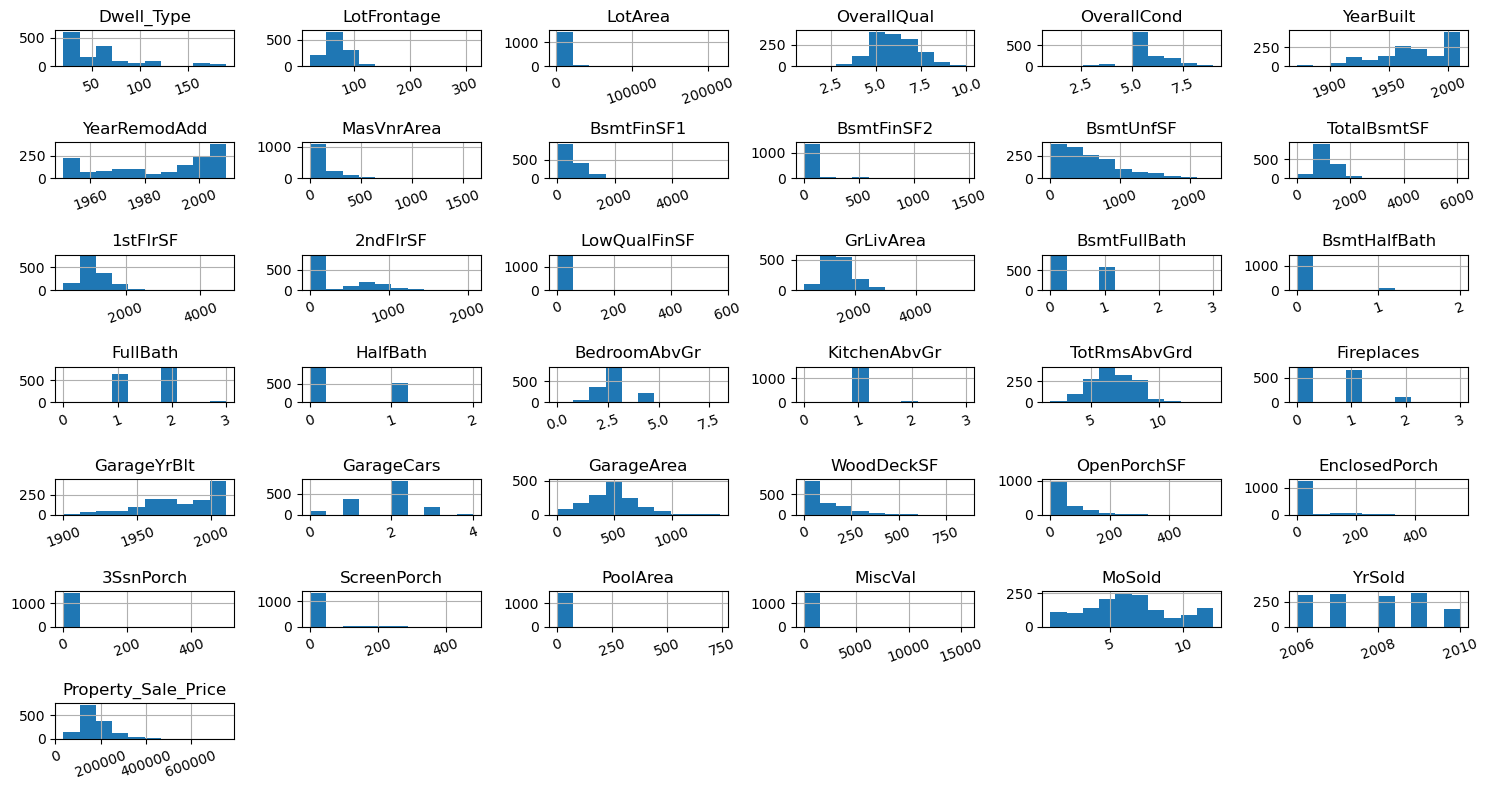

In [13]:
## visualizing thhe df_house
df_house.hist(xrot = 20)
plt.tight_layout()
plt.show()

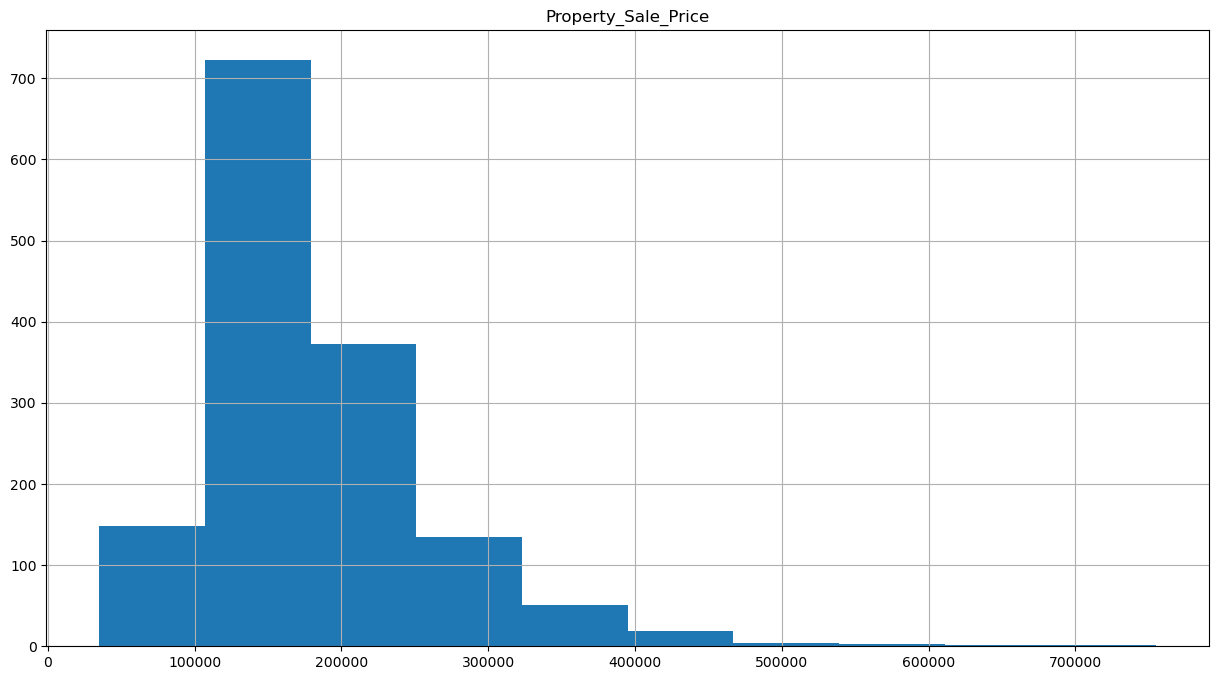

In [14]:
## visualizing the target variable
df_house.hist(['Property_Sale_Price'])
plt.show()

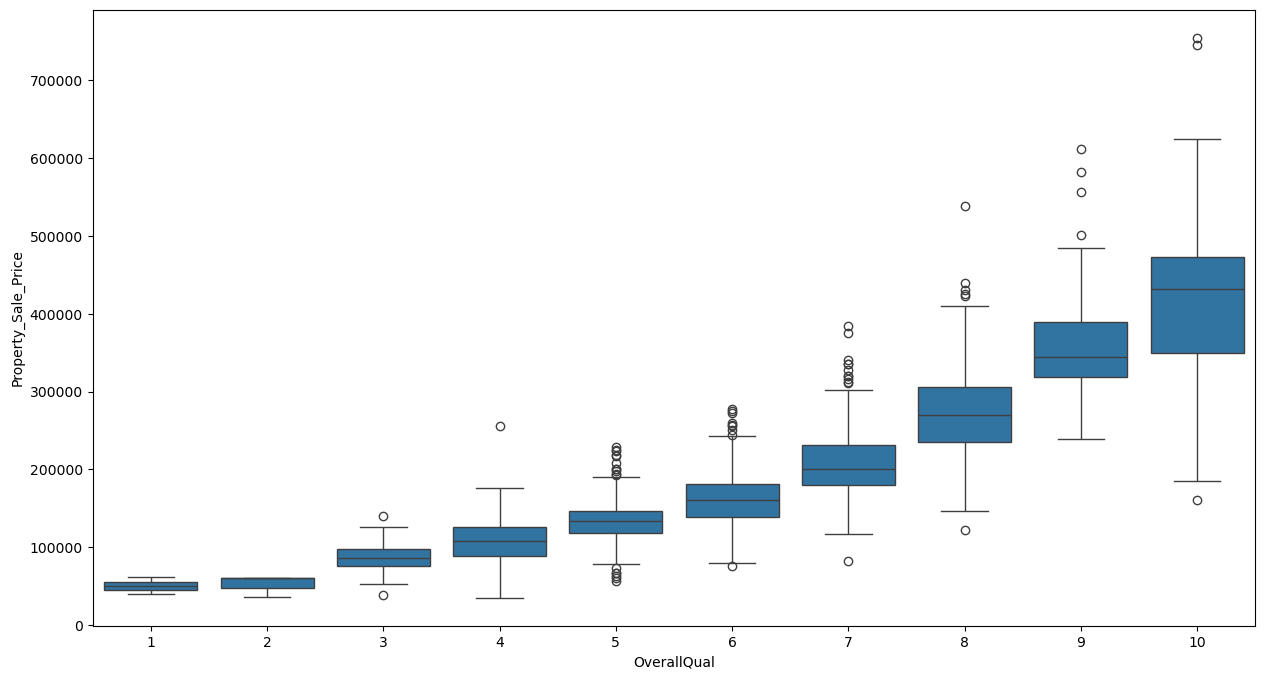

In [15]:
## the above plot shows that the target variable is positively skewed
## now comparison with OverallQual

sns.boxplot(y = 'Property_Sale_Price', x = 'OverallQual', data = df_house)
plt.show()

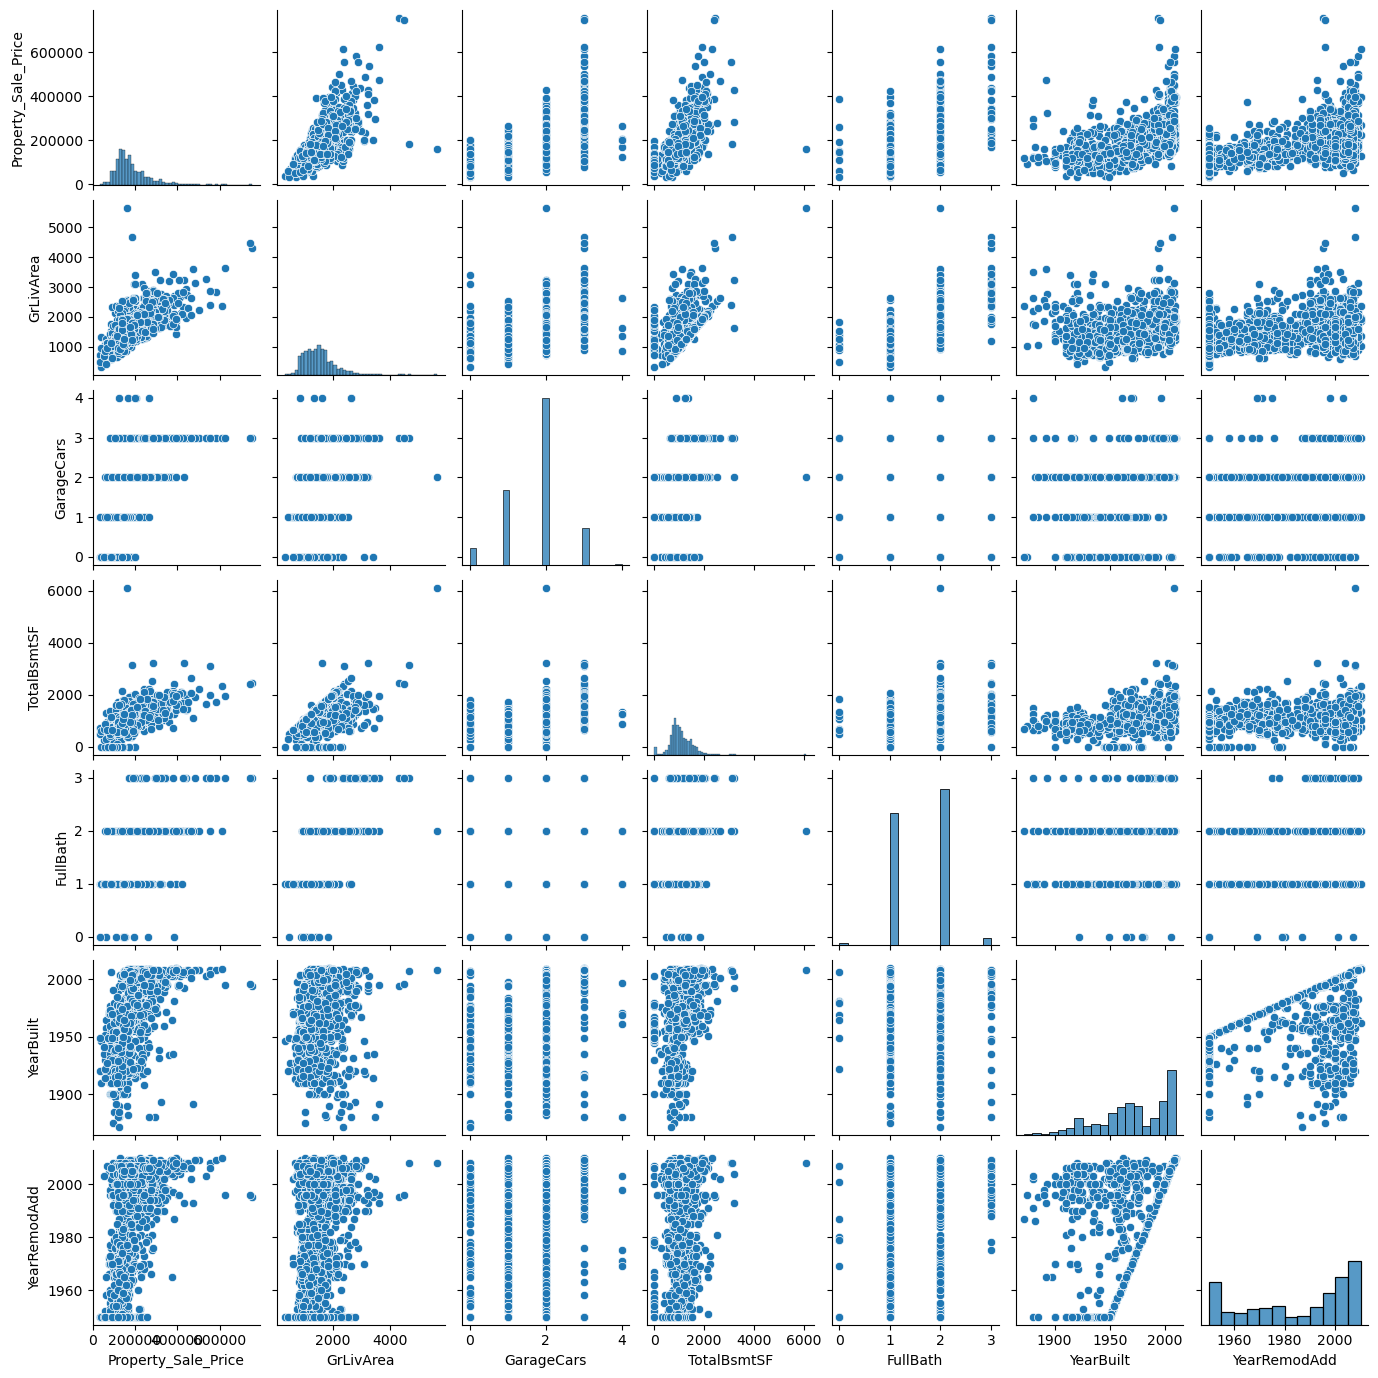

In [16]:
columns = ["Property_Sale_Price", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "YearBuilt", "YearRemodAdd"]

sns.pairplot(df_house[columns],size = 2, kind = 'scatter')
plt.show()

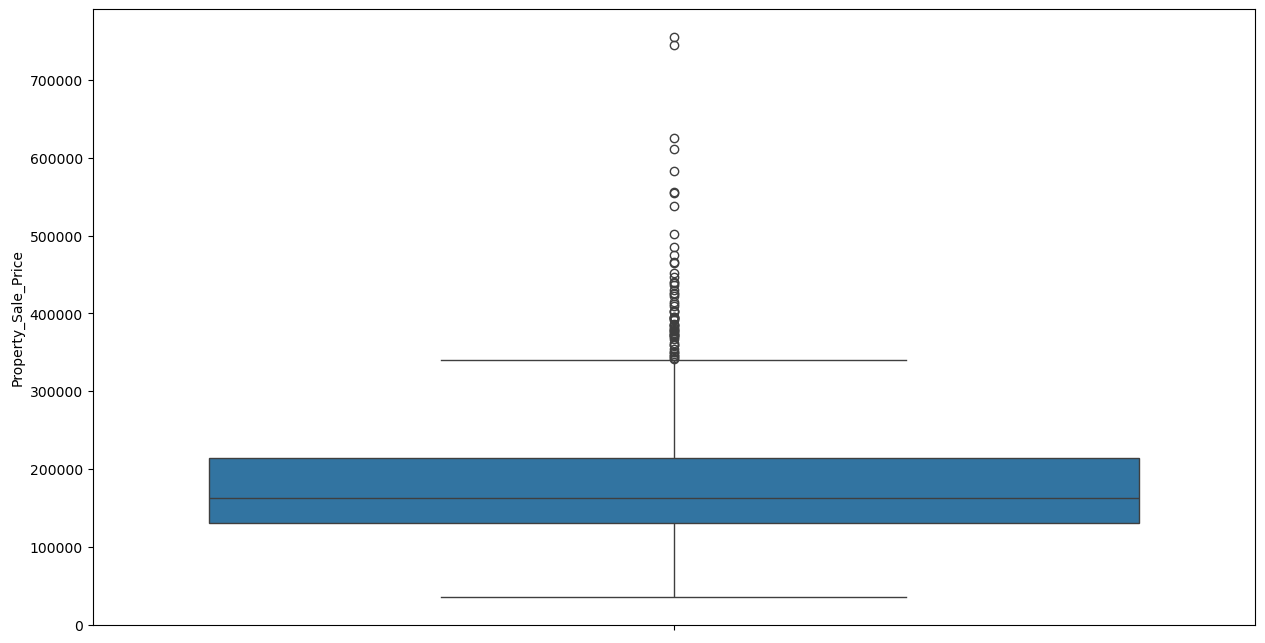

In [17]:
## outlier discovery through boxplot
sns.boxplot(df_house['Property_Sale_Price'])
plt.show()

In [18]:
df_house = df_house[df_house['Property_Sale_Price']<500000]
df_house.shape

(1451, 78)

In [19]:
## find the missing values
missing = df_house.isnull().sum().sort_values(ascending = False)
missing

Alley                  1360
Fence                  1171
MasVnrType              871
FireplaceQu             690
LotFrontage             259
GarageType               81
GarageFinish             81
GarageQual               81
GarageCond               81
GarageYrBlt              81
BsmtFinType2             38
BsmtExposure             38
BsmtQual                 37
BsmtFinType1             37
BsmtCond                 37
MasVnrArea                8
Electrical                1
BsmtFullBath              0
Functional                0
BsmtHalfBath              0
BedroomAbvGr              0
KitchenAbvGr              0
HalfBath                  0
TotRmsAbvGrd              0
Fireplaces                0
KitchenQual               0
FullBath                  0
Dwell_Type                0
LowQualFinSF              0
GarageCars                0
GarageArea                0
PavedDrive                0
WoodDeckSF                0
OpenPorchSF               0
EnclosedPorch             0
3SsnPorch           

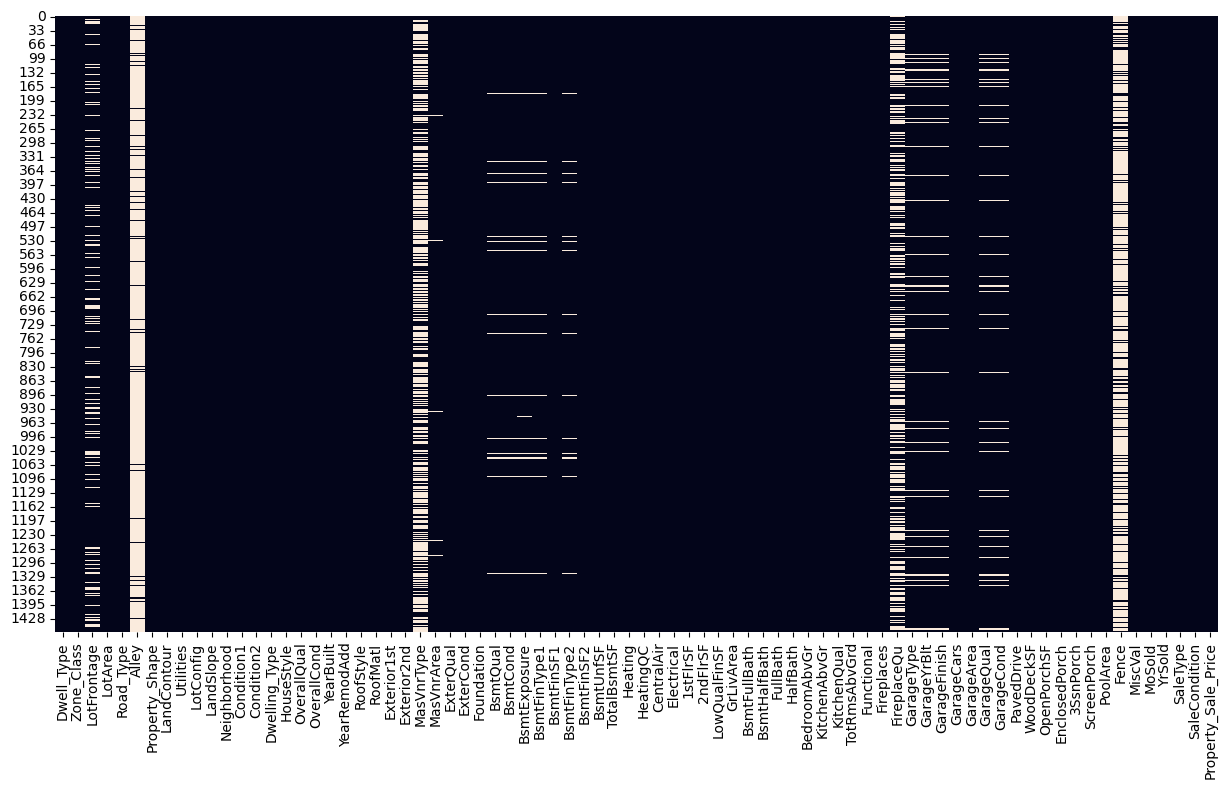

In [20]:
## visualizing the missing values

sns.heatmap(data = df_house.isnull(), cbar = False)
plt.show()

In [21]:
## treating the missing values
## get the missing value columns from numerical part 

num_miss_col = missing[(df_house.isnull().sum()>0)& (df_house.dtypes != 'object')]
num_miss_col

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64

In [22]:
df_house['LotFrontage'] = df_house['LotFrontage'].fillna(df_house['LotFrontage'].median())

In [23]:
df_house['GarageYrBlt'] = df_house['GarageYrBlt'].fillna(0)

In [24]:
df_house['MasVnrArea'] = df_house['MasVnrArea'].fillna(df_house['MasVnrArea'].median())

In [25]:
cat_miss_col = missing[(df_house.isnull().sum()>0)& (df_house.dtypes == 'object' )]
cat_miss_col

Alley           1360
Fence           1171
MasVnrType       871
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
Electrical         1
dtype: int64

In [26]:
df_house['Alley'] = df_house['Alley'].fillna('No alley access')

In [27]:
df_house['Fence'] = df_house['Fence'].fillna('No Fence')

In [28]:
df_house['FireplaceQu'] = df_house['FireplaceQu'].fillna('No Fireplace')

In [29]:
for col in ['GarageCond', 'GarageType', 'GarageFinish', 'GarageQual']:
    df_house[col].fillna('No Garage', inplace = True)

In [30]:
for col in ['BsmtFinType2', 'BsmtExposure', 'BsmtQual','BsmtCond','BsmtFinType1']:
    df_house[col].fillna('No Basement', inplace = True)

In [31]:
df_house['MasVnrType'] = df_house['MasVnrType'].fillna('None')

In [32]:
mode_electrical = df_house['Electrical'].mode()

print(mode_electrical)

0    SBrkr
Name: Electrical, dtype: object


In [33]:
df_house['Electrical'].fillna('SBrkr' , inplace = True)

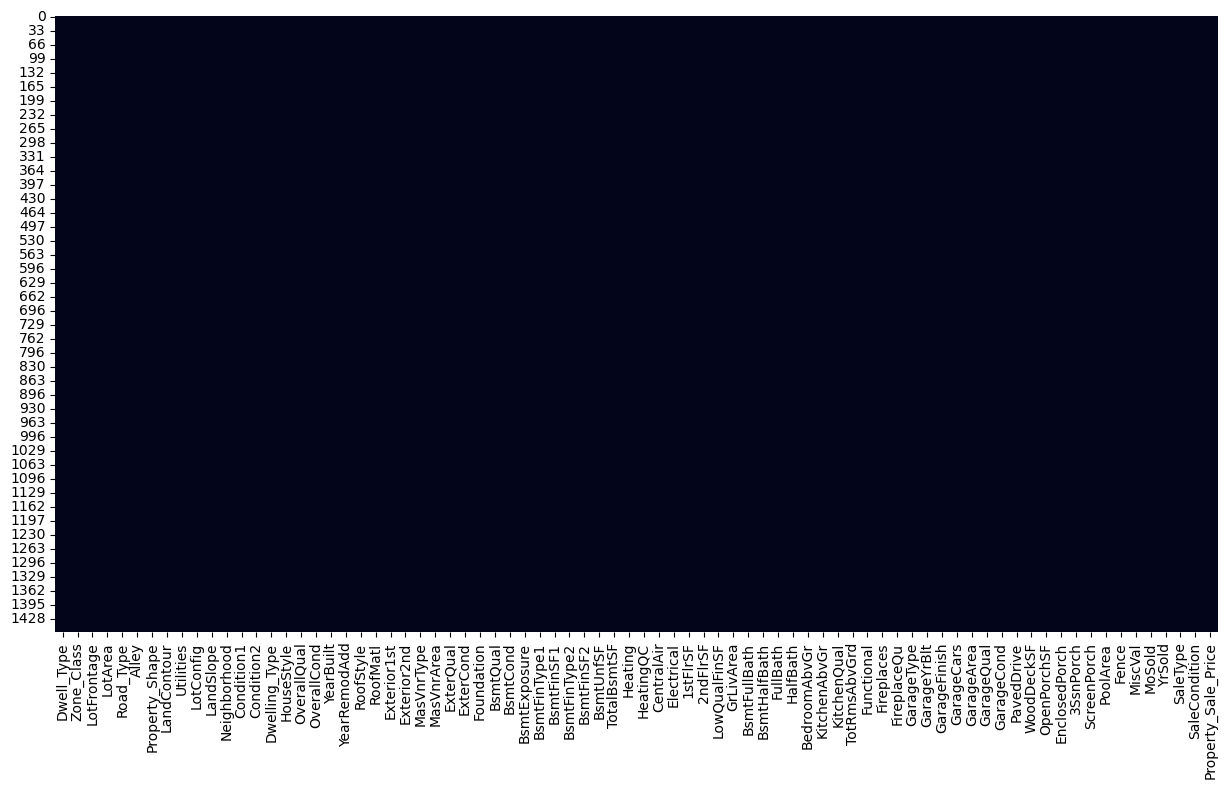

In [34]:
sns.heatmap(data = df_house.isnull(), cbar = False)
plt.show()

In [35]:
## study the correlation

corrmat = df_house.select_dtypes(include = 'number').corr()
corrmat

,Dwell_Type,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,Property_Sale_Price
Dwell_Type,1.000000,-0.359948,-0.140842,0.036824,-0.060231,0.029901,0.042606,0.028596,-0.065768,-0.064352,-0.142594,-0.239002,-0.252503,0.311621,0.046332,0.079566,0.005460,-0.002919,0.134347,0.177671,-0.026687,0.281667,0.044386,-0.043301,-0.080615,-0.037985,-0.096876,-0.014498,-0.005758,-0.012591,-0.044036,-0.025250,0.008045,-0.007821,-0.014585,-0.019381,-0.085954
LotFrontage,-0.359948,1.000000,0.306226,0.218873,-0.050642,0.110575,0.078240,0.168580,0.201974,0.041758,0.122341,0.351744,0.403928,0.055154,0.038892,0.352795,0.087810,-0.009650,0.166976,0.039602,0.233933,-0.003219,0.311321,0.223229,0.097975,0.261254,0.317880,0.073205,0.133322,0.013371,0.063617,0.035947,0.154557,0.000464,0.015944,0.009395,0.318744
LotArea,-0.140842,0.306226,1.000000,0.092573,-0.002507,0.007052,0.007963,0.079576,0.204725,0.113638,-0.002229,0.253819,0.293575,0.033593,0.005727,0.248741,0.154564,0.047356,0.111174,0.006873,0.114221,-0.016372,0.175347,0.268811,0.071133,0.145224,0.171107,0.159650,0.084143,-0.015829,0.021493,0.032825,0.079291,0.039093,0.003327,-0.016991,0.252156
OverallQual,0.036824,0.218873,0.092573,1.000000,-0.087809,0.569569,0.549306,0.389042,0.216929,-0.062754,0.309207,0.519780,0.456487,0.281649,-0.029207,0.577533,0.106587,-0.045858,0.539019,0.268238,0.097513,-0.184125,0.407980,0.386322,0.289973,0.592229,0.552794,0.234836,0.307595,-0.110743,0.032642,0.055887,0.042913,-0.030682,0.081077,-0.029227,0.802424
OverallCond,-0.060231,-0.050642,-0.002507,-0.087809,1.000000,-0.374705,0.076615,-0.125842,-0.041916,0.040844,-0.137000,-0.168898,-0.141383,0.032440,0.025204,-0.075899,-0.053159,0.116845,-0.192336,-0.059294,0.013622,-0.087629,-0.052043,-0.021176,-0.005742,-0.183182,-0.148636,-0.002397,-0.031102,0.069509,0.025223,0.058424,0.002957,0.068605,-0.004147,0.045267,-0.072195
YearBuilt,0.029901,0.110575,0.007052,0.569569,-0.374705,1.000000,0.590358,0.308832,0.242388,-0.050381,0.147484,0.385072,0.272635,0.002106,-0.183659,0.188173,0.185755,-0.039128,0.464424,0.239822,-0.073171,-0.174064,0.081196,0.140979,0.271118,0.533519,0.474181,0.223873,0.186221,-0.386450,0.032225,-0.057585,-0.002602,-0.033934,0.016370,-0.016129,0.543898
YearRemodAdd,0.042606,0.078240,0.007963,0.549306,0.076615,0.590358,1.000000,0.170015,0.120246,-0.069146,0.179966,0.284008,0.232100,0.136997,-0.061920,0.283858,0.117521,-0.012512,0.436448,0.180804,-0.041872,-0.148847,0.181722,0.106649,0.145115,0.416036,0.366411,0.205597,0.224186,-0.192517,0.046070,-0.045230,0.001135,-0.009821,0.025102,0.033392,0.531708
MasVnrArea,0.028596,0.168580,0.079576,0.389042,-0.125842,0.308832,0.170015,1.000000,0.237426,-0.070851,0.116437,0.340365,0.318259,0.150374,-0.069527,0.358948,0.078313,0.015343,0.251721,0.192394,0.099591,-0.036336,0.254011,0.238226,0.133385,0.351166,0.357034,0.145807,0.122038,-0.108352,0.022121,0.057424,0.020565,-0.029244,0.005738,-0.010231,0.436515
BsmtFinSF1,-0.065768,0.201974,0.204725,0.216929,-0.041916,0.242388,0.120246,0.237426,1.000000,-0.054443,-0.502348,0.506796,0.427145,-0.160550,-0.064339,0.177440,0.652108,0.065858,0.039019,-0.003163,-0.108698,-0.080020,0.016513,0.245847,0.114548,0.209144,0.283615,0.202566,0.112177,-0.099877,0.028548,0.057946,0.117131,0.004795,-0.010615,0.008691,0.357076
BsmtFinSF2,-0.064352,0.041758,0.113638,-0.062754,0.040844,-0.050381,-0.069146,-0.070851,-0.054443,1.000000,-0.211681,0.101582,0.096551,-0.096758,0.014921,-0.008304,0.158017,0.072546,-0.076080,-0.029227,-0.012647,-0.040788,-0.036589,0.044752,0.035023,-0.039581,-0.017447,0.071761,0.003118,0.036869,-0.030038,0.085238,0.047831,0.005002,-0.014359,0.030290,-0.014028


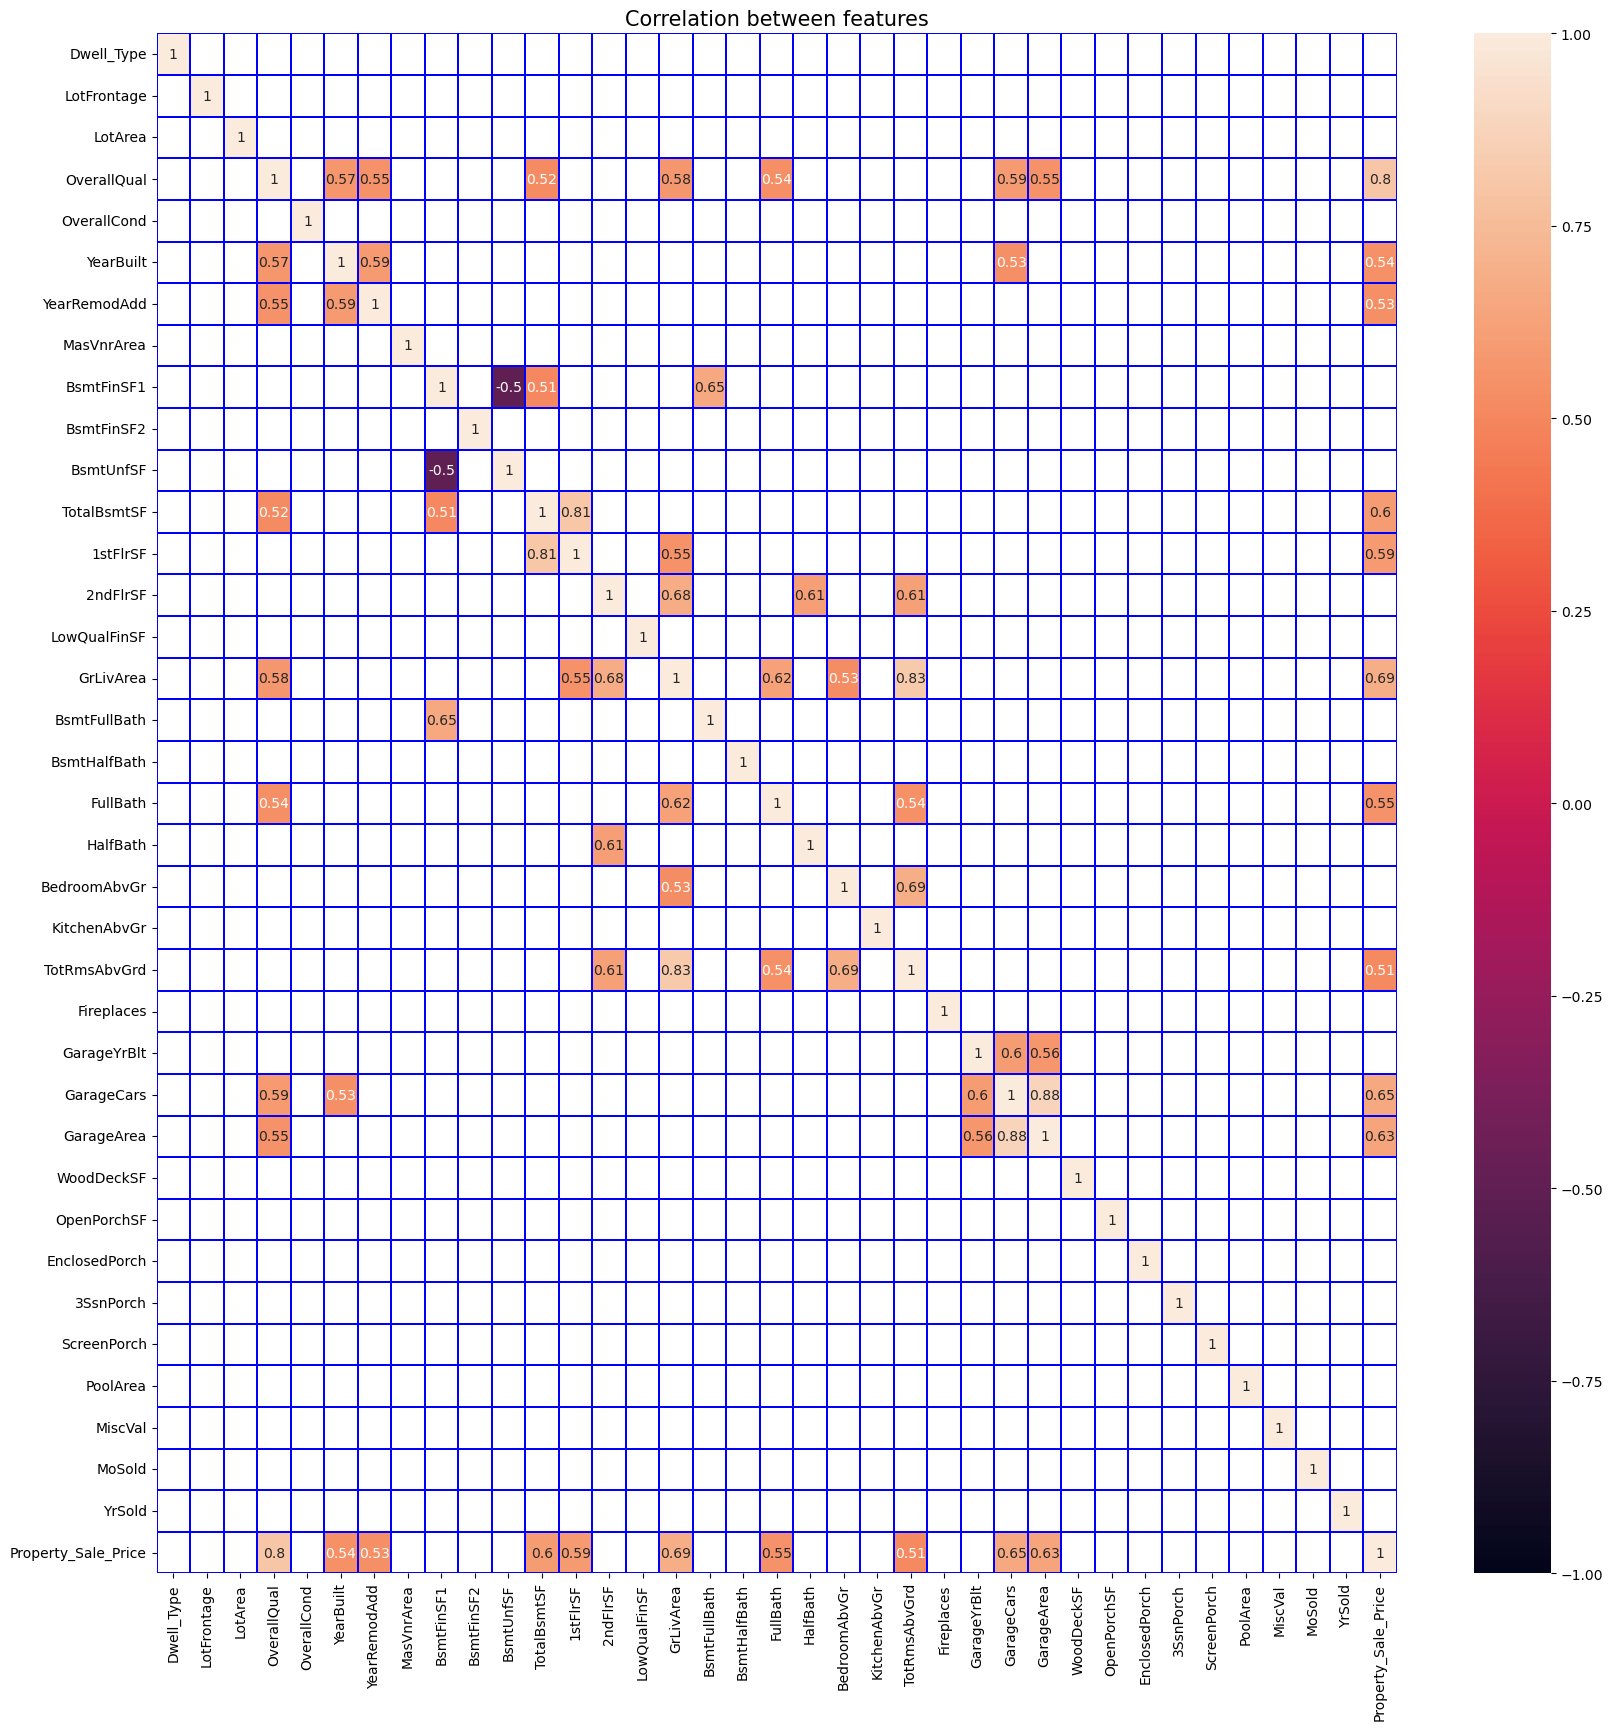

In [36]:
## visualize the corr 
correlation = df_house.select_dtypes(include = 'number').corr()
plt.figure(figsize=(20, 20))
sns.heatmap(correlation[(correlation >= 0.5) | (correlation <= -0.5)],
            annot=True,linewidths=.1,linecolor="blue",vmax = 1, vmin = -1)
plt.title('Correlation between features', fontsize=15)
plt.show()

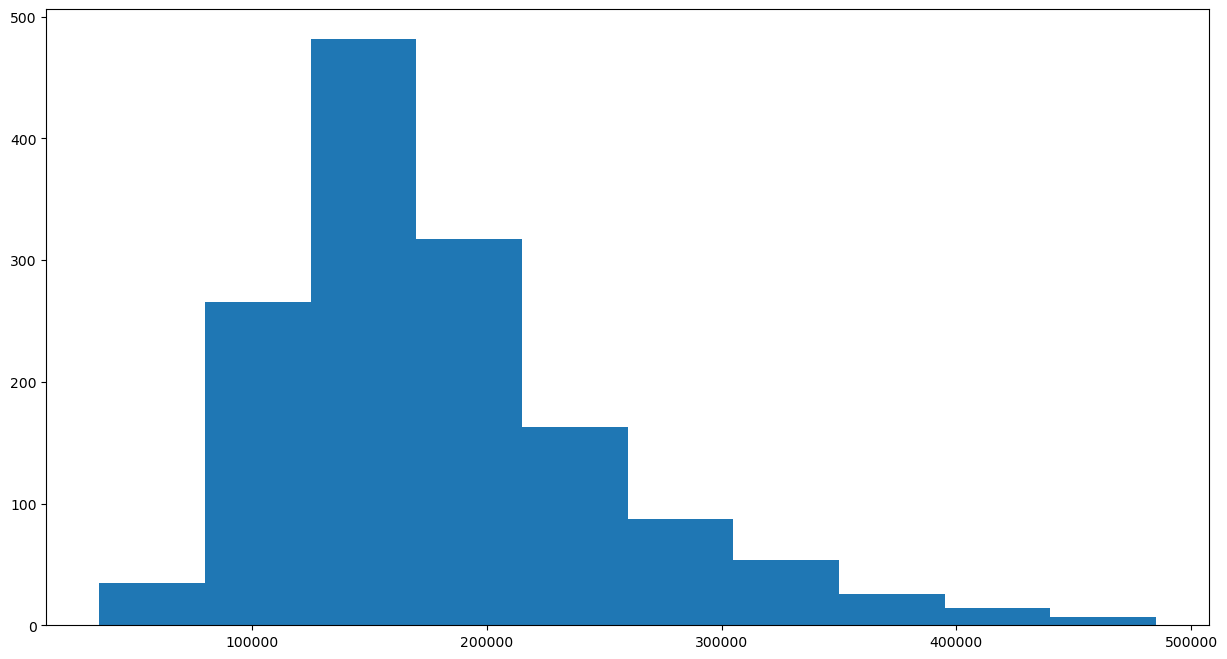

In [37]:
## now we have to check normality
plt.hist(df_house.Property_Sale_Price)
plt.show()

In [38]:
## now we wil go for the shapiro test because the dta is less thatn 5000

stat, p = shapiro(df_house.Property_Sale_Price)

print(f'stats:{stat}, p_value:{p}')

alpha = 0.05
if p>alpha:
    print('the data is normally distributed')
else:
    print('the data is not normally distributed')

stats:0.9194354886875163, p_value:3.87864903704238e-27
the data is not normally distributed


In [39]:
## to normally distribute the data we will do the log transformation

df_house['log_Property_Sale_Price'] = np.log(df_house['Property_Sale_Price'])


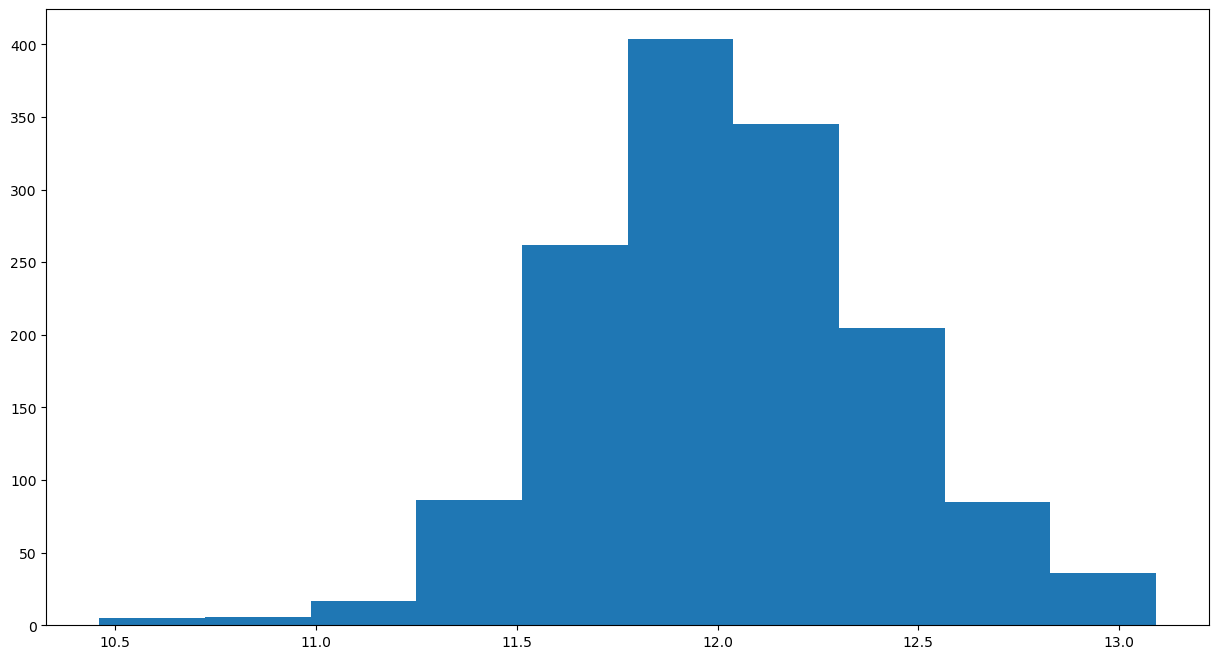

In [58]:
## recheck the normallity
plt.hist(df_house['log_Property_Sale_Price'])
plt.show()

In [59]:
## again do the shapiro test
stat, p = shapiro(df_house['log_Property_Sale_Price'])

print(f'stat:{stat}, p_value:{p}')
alpha = 0.05

if p> alpha:
    print('the data is normally distributed')
else:
    print('the data is not normally distributed')

stat:0.9924852006371634, p_value:9.52779805088766e-07
the data is not normally distributed


In [60]:
## dummy encode the data 
##separate the numerical data 
df_house_num = df_house.select_dtypes(include = np.number)
df_house_num.columns

Index(['Dwell_Type', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'Property_Sale_Price', 'log_Property_Sale_Price'],
      dtype='object')

In [61]:
df_house_cat = df_house.select_dtypes(include = 'object')
df_house_cat.columns

Index(['Zone_Class', 'Road_Type', 'Alley', 'Property_Shape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'Dwelling_Type', 'HouseStyle', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'Fence',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [62]:
## dummy encode the cat variable
cat_dummy = pd.get_dummies(df_house_cat, drop_first = True)
cat_dummy.shape

(1451, 216)

In [45]:
df_house_dummy = pd.concat([df_house_num, cat_dummy], axis = 1)
df_house_dummy.head()

,Dwell_Type,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,Property_Sale_Price,log_Property_Sale_Price,Zone_Class_FV,Zone_Class_RH,Zone_Class_RL,Zone_Class_RM,Road_Type_Pave,Alley_No alley access,Alley_Pave,Property_Shape_IR2,Property_Shape_IR3,Property_Shape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,Dwelling_Type_2fmCon,Dwelling_Type_Duplex,Dwelling_Type_Twnhs,Dwelling_Type_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_No Basement,BsmtQual_TA,BsmtCond_Gd,BsmtCond_No Basement,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtExposure_No Basement,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_No Basement,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_No Basement,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_No Fireplace,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_No Garage,GarageFinish_No Garage,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_No Garage,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_No Garage,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_No Fence,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,

In [46]:
df_house_dummy.shape

(1451, 254)

In [47]:
## create the linear regression model

df_house_dummy = sm.add_constant(df_house_dummy)

x = df_house_dummy.drop(['log_Property_Sale_Price','Property_Sale_Price'], axis = 1)
y = df_house_dummy[['log_Property_Sale_Price', 'Property_Sale_Price']]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 1)

print('x_train',x_train.shape)
print('x_test',x_test.shape)
print('y_trian',y_train.shape)
print('y_test',y_test.shape)

x_train (1015, 253)
x_test (436, 253)
y_trian (1015, 2)
y_test (436, 2)


In [48]:
## building the model
linreg_log = sm.OLS(y_train['log_Property_Sale_Price'].astype(float), x_train.astype(float)).fit()

In [49]:
linreg_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     log_Property_Sale_Price   R-squared:                       0.949
Model:                                 OLS   Adj. R-squared:                  0.933
Method:                      Least Squares   F-statistic:                     60.95
Date:                     Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                             14:02:47   Log-Likelihood:                 1054.5
No. Observations:                     1015   AIC:                            -1635.
Df Residuals:                          778   BIC:                            -468.4
Df Model:                              236                                         
Covariance Type:                 nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        6.4926      4.616      1.407      0.160      -2.568      15.553
Dwell_Type               -2.889e-05      0.000     -0.062      0.951      -0.001       0.001
LotFrontage                  0.0003      0.000      1.342      0.180      -0.000       0.001
LotArea                   3.281e-06   5.85e-07      5.610      0.000    2.13e-06    4.43e-06
OverallQual                  0.0361      0.006      6.526      0.000       0.025       0.047
OverallCond                  0.0377      0.005      8.251      0.000       0.029       0.047
YearBuilt                    0.0023      0.000      5.286      0.000       0.001       0.003
YearRemodAdd                 0.0009      0.000      3.192      0.001       0.000       0.002
MasVnrArea                7.547e-06    3.3e-05      0.229      0.819   -5.72e-05    7.23e-05
BsmtFinSF1                 6.64e-05   1.58e-05      4.211      0.000    3.55e-05    9.74e-05
BsmtFinSF2                3.564e-05   3.15e-05      1.132      0.258   -2.62e-05    9.75e-05
BsmtUnfSF                -7.101e-06   1.49e-05     -0.477      0.633   -3.63e-05    2.21e-05
TotalBsmtSF               9.494e-05    2.2e-05      4.310      0.000    5.17e-05       0.000
1stFlrSF                     0.0001   3.44e-05      2.935      0.003    3.35e-05       0.000
2ndFlrSF                  7.824e-05   3.17e-05      2.469      0.014     1.6e-05       0.000
LowQualFinSF             -2.007e-05   7.55e-05     -0.266      0.791      -0.000       0.000
GrLivArea                    0.0002   2.97e-05      5.353      0.000       0.000       0.000
BsmtFullBath                 0.0194      0.011      1.824      0.069      -0.001       0.040
BsmtHalfBath                 0.0158      0.016      1.003      0.316      -0.015       0.047
FullBath                     0.0051      0.012      0.421      0.674      -0.019       0.029
HalfBath                     0.0114      0.011      1.033      0.302      -0.010       0.033
BedroomAbvGr                 0.0175      0.008      2.327      0.020       0.003       0.032
KitchenAbvGr                -0.0410      0.034     -1.201      0.230      -0.108       0.026
TotRmsAbvGrd                -0.0025      0.005     -0.498      0.619      -0.013       0.007
Fireplaces                   0.0123      0.014      0.910      0.363      -0.014       0.039
GarageYrBlt              -4.625e-05      0.000     -0.139      0.889      -0.001       0.001
GarageCars                   0.0309      0.012      2.486      0.013       0.007       0.055
GarageArea                7.532e-05   4.46e-05      1.688      0.092   -1.23e-05       0.000
WoodDeckSF                6.424e-05   3.29e-05      1.952      0.051   -3.69e-07       0.000
OpenPorchSF                  0.0001   6.29e-05      

In [50]:
linreg_log_pred = linreg_log.predict(x_test)

In [51]:
predicted_price = np.exp(linreg_log_pred.astype('float'))
actual_sale_price = y_test['log_Property_Sale_Price']

In [52]:
## get the rmse using rmse
from statsmodels.tools.eval_measures import rmse
linreg_log_rmse = rmse(predicted_price, actual_sale_price)
linreg_log_r2_score = linreg_log.rsquared
linreg_log_adjusted_r2 = linreg_log.rsquared_adj

In [53]:
result = pd.DataFrame([{
    'Model': 'Linreg with log of target variable',
    'RMSE': linreg_log_rmse,
    'r_squared': linreg_log_r2_score,
    'adj_rsquared': linreg_log_adjusted_r2
}])
result

,Model,RMSE,r_squared,adj_rsquared
0,Linreg with log of target variable,199633.711968,0.948687,0.933121


In [70]:
df_house.to_csv("clean_dataset.csv", index=False)